In [1]:
# Load frozen probabilities and labels, restrict to test-main, rebuild the operating
# point. Gate: must reproduce M1 291 TP / M2 216 TP at the frozen thresholds.
from pathlib import Path
import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MODELS, TABLES, FIGS = ROOT/"outputs"/"models", ROOT/"outputs"/"tables", ROOT/"outputs"/"figures"
PROC = ROOT/"data"/"processed"

p1 = pd.read_parquet(MODELS/"m1_test_probs.parquet")
p2 = pd.read_parquet(MODELS/"m2_test_probs.parquet")
thr1 = json.load(open(MODELS/"06_m1_threshold.json"))
thr2 = json.load(open(MODELS/"07_m2_threshold.json"))
labels = pd.read_parquet(PROC/"05_features_full.parquet", columns=["Is Laundering"])

d = p1.join(p2["m2_prob"]).join(labels, how="left")
main = d[d["is_main"]].copy()
main["y"] = main["Is Laundering"].astype(int)

t1, t2 = thr1["threshold"], thr2["threshold"]
print("rows:", len(main), "| illicit:", int(main["y"].sum()))
print("M1 TP at frozen threshold:", int(((main.m1_prob >= t1) & (main.y == 1)).sum()))
print("M2 TP at frozen threshold:", int(((main.m2_prob >= t2) & (main.y == 1)).sum()))

rows: 760531 | illicit: 906
M1 TP at frozen threshold: 291
M2 TP at frozen threshold: 216


In [2]:
# Rank every transaction by score and take the top k as the day's alert queue.
# Threshold-free: compares the models at equal analyst workload.
BUDGETS = [100, 250, 500, 1000, 2500, 5000, 10000]
n_ill = int(main["y"].sum())
rows = []
for k in BUDGETS:
    for name, col in (("M1", "m1_prob"), ("M2", "m2_prob")):
        top = main.nlargest(k, col)          # the k highest-scoring transactions
        tp = int(top["y"].sum())
        rows.append({"budget_k": k, "model": name, "true_positives": tp,
                     "precision_at_k": tp/k, "recall_at_k": tp/n_ill})

ab = pd.DataFrame(rows).pivot(index="budget_k", columns="model",
                              values=["true_positives", "precision_at_k", "recall_at_k"])
print(ab.round(4).to_string())

flat = pd.DataFrame(rows)
flat["m2_minus_m1_tp"] = flat.groupby("budget_k")["true_positives"].diff()
print("\nM2 - M1 true positives by budget:")
print(flat.dropna(subset=["m2_minus_m1_tp"])[["budget_k", "m2_minus_m1_tp"]].to_string(index=False))

         true_positives        precision_at_k         recall_at_k        
model                M1     M2             M1      M2          M1      M2
budget_k                                                                 
100                37.0   22.0         0.3700  0.2200      0.0408  0.0243
250                60.0   55.0         0.2400  0.2200      0.0662  0.0607
500                97.0   84.0         0.1940  0.1680      0.1071  0.0927
1000              163.0  130.0         0.1630  0.1300      0.1799  0.1435
2500              243.0  208.0         0.0972  0.0832      0.2682  0.2296
5000              338.0  316.0         0.0676  0.0632      0.3731  0.3488
10000             458.0  451.0         0.0458  0.0451      0.5055  0.4978

M2 - M1 true positives by budget:
 budget_k  m2_minus_m1_tp
      100           -15.0
      250            -5.0
      500           -13.0
     1000           -33.0
     2500           -35.0
     5000           -22.0
    10000            -7.0


written: c:\Fintech-Project\graph_AML_pipeline\outputs\tables\12_alert_budget.csv | c:\Fintech-Project\graph_AML_pipeline\outputs\figures\12_alert_budget_recall.png


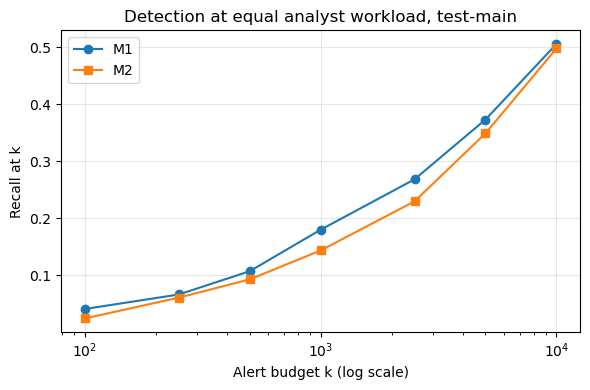

In [3]:
# Persist the alert-budget table, then plot recall vs budget for both models.
flat.to_csv(TABLES / "12_alert_budget.csv", index=False)

fig, ax = plt.subplots(figsize=(6, 4))
for name, mk in (("M1", "o"), ("M2", "s")):
    s = flat[flat.model == name]
    ax.plot(s.budget_k, s.recall_at_k, marker=mk, label=name)
ax.set_xscale("log")
ax.set_xlabel("Alert budget k (log scale)")
ax.set_ylabel("Recall at k")
ax.set_title("Detection at equal analyst workload, test-main")
ax.legend(); ax.grid(alpha=.3)
fig.tight_layout()
fig.savefig(FIGS / "12_alert_budget_recall.png", dpi=300)
print("written:", TABLES/"12_alert_budget.csv", "|", FIGS/"12_alert_budget_recall.png")